In [1]:
# Install required packages
!pip install opencv-python-headless albumentations -q

In [2]:
# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Configuration & Constants

Based on EDA findings, we define the canonical format.

In [3]:
# ============================================
# CANONICAL INPUT FORMAT
# ============================================
TARGET_HEIGHT = 128      # Fixed height for all images
TARGET_WIDTH = 768       # Maximum width (covers 99%+ of IM2LATEX)
NUM_CHANNELS = 1         # Grayscale
PAD_VALUE = 255          # White padding

# ============================================
# DATASET STATISTICS (from EDA)
# ============================================
# IM2LATEX statistics
IM2LATEX_MEAN = 0.9449
IM2LATEX_STD = 0.1888

# CROHME statistics (original)
CROHME_MEAN = 0.9889
CROHME_STD = 0.1032

# ============================================
# DATA PATHS
# ============================================
IM2LATEX_IMG_PATH = Path("/app/data/IM2LATEX/image")
IM2LATEX_LABEL_PATH = Path("/app/data/IM2LATEX/label")
CROHME_IMG_PATH = Path("/app/data/CHROME/ground_truth/images")
CROHME_CSV_PATH = Path("/app/data/CHROME/ground_truth/dataset.csv")

# Output paths for preprocessed data
OUTPUT_PATH = Path("/app/data/preprocessed")
OUTPUT_PATH.mkdir(exist_ok=True, parents=True)

IM2LATEX_OUTPUT_PATH = OUTPUT_PATH / "im2latex"
CROHME_OUTPUT_PATH = OUTPUT_PATH / "crohme"
IM2LATEX_OUTPUT_PATH.mkdir(exist_ok=True)
CROHME_OUTPUT_PATH.mkdir(exist_ok=True)

print(f"Target format: [{NUM_CHANNELS}, {TARGET_HEIGHT}, {TARGET_WIDTH}]")
print(f"\nOutput paths:")
print(f"  IM2LATEX: {IM2LATEX_OUTPUT_PATH}")
print(f"  CROHME: {CROHME_OUTPUT_PATH}")

Target format: [1, 128, 768]

Output paths:
  IM2LATEX: /app/data/preprocessed/im2latex
  CROHME: /app/data/preprocessed/crohme


---

## Helper Functions: Core Preprocessing Operations

These functions implement the canonical format transformation.

In [4]:
def convert_to_grayscale(image):
    """
    Convert image to grayscale.
    
    Args:
        image: PIL Image or numpy array
    
    Returns:
        Grayscale numpy array (H, W)
    """
    if isinstance(image, Image.Image):
        if image.mode != 'L':
            image = image.convert('L')
        return np.array(image)
    
    if len(image.shape) == 3:
        if image.shape[2] == 3:
            return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        elif image.shape[2] == 4:
            return cv2.cvtColor(image, cv2.COLOR_BGRA2GRAY)
    
    return image


def resize_keep_aspect_ratio(image, target_height=TARGET_HEIGHT):
    """
    Resize image to target height while preserving aspect ratio.
    
    Args:
        image: numpy array (H, W)
        target_height: target height in pixels
    
    Returns:
        Resized image (target_height, new_width)
    """
    h, w = image.shape[:2]
    
    # Calculate new width maintaining aspect ratio
    aspect_ratio = w / h
    new_width = int(target_height * aspect_ratio)
    
    # Resize
    resized = cv2.resize(image, (new_width, target_height), interpolation=cv2.INTER_AREA)
    
    return resized


def pad_to_width(image, target_width=TARGET_WIDTH, pad_value=PAD_VALUE):
    """
    Pad image to target width with white padding on the right.
    If image is wider than target, resize it to fit.
    
    Args:
        image: numpy array (H, W)
        target_width: target width in pixels
        pad_value: padding pixel value (255 = white)
    
    Returns:
        Padded image (H, target_width)
    """
    h, w = image.shape[:2]
    
    if w > target_width:
        # If image is too wide, resize to fit
        scale = target_width / w
        new_h = int(h * scale)
        image = cv2.resize(image, (target_width, new_h), interpolation=cv2.INTER_AREA)
        
        # Pad vertically if needed
        if new_h < TARGET_HEIGHT:
            pad_h = TARGET_HEIGHT - new_h
            image = cv2.copyMakeBorder(image, 0, pad_h, 0, 0, 
                                      cv2.BORDER_CONSTANT, value=pad_value)
        return image
    
    # Pad on the right
    pad_width = target_width - w
    padded = cv2.copyMakeBorder(image, 0, 0, 0, pad_width, 
                                cv2.BORDER_CONSTANT, value=pad_value)
    
    return padded


def crop_content(image, margin=5):
    """
    Crop image to bounding box of content (non-white pixels).
    Essential for CROHME to remove excess whitespace.
    
    Args:
        image: numpy array (H, W), grayscale
        margin: pixels to add around content
    
    Returns:
        Cropped image
    """
    # Threshold to binary (find non-white pixels)
    binary = (image < 250).astype(np.uint8)
    
    # Find contours
    coords = cv2.findNonZero(binary)
    
    if coords is None:
        # Empty image, return as is
        return image
    
    # Get bounding box
    x, y, w, h = cv2.boundingRect(coords)
    
    # Add margin
    x = max(0, x - margin)
    y = max(0, y - margin)
    w = min(image.shape[1] - x, w + 2 * margin)
    h = min(image.shape[0] - y, h + 2 * margin)
    
    # Crop
    cropped = image[y:y+h, x:x+w]
    
    return cropped


def normalize_image(image, mean=0.0, std=1.0):
    """
    Normalize image to [0, 1] range, then standardize.
    
    Args:
        image: numpy array
        mean: normalization mean
        std: normalization std
    
    Returns:
        Normalized image (float32)
    """
    # Convert to [0, 1]
    image = image.astype(np.float32) / 255.0
    
    # Standardize
    if std > 0:
        image = (image - mean) / std
    
    return image


def per_image_normalize(image):
    """
    Per-image normalization (zero mean, unit variance).
    Important for CROHME handwritten images.
    
    Args:
        image: numpy array
    
    Returns:
        Normalized image
    """
    image = image.astype(np.float32) / 255.0
    mean = image.mean()
    std = image.std()
    
    if std > 0:
        image = (image - mean) / std
    
    return image


print("✓ Helper functions loaded")

✓ Helper functions loaded


---

## IM2LATEX Preprocessing Pipeline

**Strategy**: Keep images sharp and clean, minimal processing.

### Pipeline Steps:
1. Convert to grayscale
2. Resize to fixed height (128) keeping aspect ratio
3. Pad to fixed width (768)
4. Light normalization (using dataset statistics)
5. Optional: Very light blur (low probability)

In [5]:
def preprocess_im2latex(image_path, augment=False):
    """
    Preprocess IM2LATEX image to canonical format.
    
    Args:
        image_path: path to image file
        augment: whether to apply augmentation (for training)
    
    Returns:
        Preprocessed image (128, 768) or None if error
    """
    try:
        # Load image
        image = Image.open(image_path)
        
        # Step 1: Convert to grayscale
        image = convert_to_grayscale(image)
        
        # Step 2: Resize keeping aspect ratio
        image = resize_keep_aspect_ratio(image, TARGET_HEIGHT)
        
        # Step 3: Pad to target width
        image = pad_to_width(image, TARGET_WIDTH)
        
        # Step 4: Light augmentation (optional, for training only)
        if augment:
            transform = A.Compose([
                A.GaussianBlur(blur_limit=(3, 3), p=0.1),  # Very light blur
                A.RandomBrightnessContrast(
                    brightness_limit=0.1, 
                    contrast_limit=0.1, 
                    p=0.2
                ),
            ])
            image = transform(image=image)['image']
        
        # Step 5: Normalize (light normalization)
        # Keep close to original distribution
        image = image.astype(np.float32) / 255.0
        
        return image
    
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None


print("✓ IM2LATEX preprocessing pipeline ready")

✓ IM2LATEX preprocessing pipeline ready


---

## CROHME Preprocessing Pipeline

**Strategy**: Remove whitespace, enhance contrast, aggressive augmentation.

### Pipeline Steps:
1. Convert to grayscale
2. **Crop content** (remove excess whitespace)
3. Resize to fixed height (128) keeping aspect ratio
4. Pad to fixed width (768)
5. **Per-image normalization** (important!)
6. **Contrast enhancement**
7. Augmentation: brightness, contrast, thickness variation

In [6]:
def preprocess_crohme(image_path, augment=False):
    """
    Preprocess CROHME image to canonical format.
    Includes content cropping and contrast enhancement.
    
    Args:
        image_path: path to image file
        augment: whether to apply augmentation (for training)
    
    Returns:
        Preprocessed image (128, 768) or None if error
    """
    try:
        # Load image
        image = Image.open(image_path)
        
        # Step 1: Convert to grayscale
        image = convert_to_grayscale(image)
        
        # Step 2: CRITICAL - Crop content (remove whitespace)
        image = crop_content(image, margin=10)
        
        # Step 3: Resize keeping aspect ratio
        image = resize_keep_aspect_ratio(image, TARGET_HEIGHT)
        
        # Step 4: Pad to target width
        image = pad_to_width(image, TARGET_WIDTH)
        
        # Step 5: Augmentation (for training)
        if augment:
            transform = A.Compose([
                # Contrast enhancement (CROHME has low contrast)
                A.RandomBrightnessContrast(
                    brightness_limit=0.2,
                    contrast_limit=0.3,
                    p=0.7
                ),
                # Simulate different pen thickness
                A.OneOf([
                    A.Sharpen(alpha=(0.2, 0.5), p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                ], p=0.3),
                # Simulate rotation/skew
                A.Rotate(limit=5, border_mode=cv2.BORDER_CONSTANT, 
                        value=255, p=0.3),
            ])
            image = transform(image=image)['image']
        
        # Step 6: Per-image normalization (CRITICAL for handwriting)
        image = per_image_normalize(image)
        
        return image
    
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None


print("✓ CROHME preprocessing pipeline ready")

✓ CROHME preprocessing pipeline ready


---

## Visualization: Compare Original vs Preprocessed

Let's verify the preprocessing pipelines visually.

In [7]:
# Load sample datasets
im2latex_train = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_train.csv")
crohme_df = pd.read_csv(CROHME_CSV_PATH)

print(f"IM2LATEX samples: {len(im2latex_train):,}")
print(f"CROHME samples: {len(crohme_df):,}")

IM2LATEX samples: 75,275
CROHME samples: 18,855


In [50]:
def visualize_preprocessing(dataset_type='im2latex', num_samples=3):
    """
    Visualize original vs preprocessed images with BORDER around plots.
    """
    if dataset_type == 'im2latex':
        df = im2latex_train.sample(n=num_samples, random_state=42)
        img_paths = [IM2LATEX_IMG_PATH / img for img in df['image'].values]
        preprocess_fn = preprocess_im2latex
    else:
        df = crohme_df.sample(n=num_samples, random_state=42)
        img_paths = [CROHME_IMG_PATH / img for img in df['image'].values]
        preprocess_fn = preprocess_crohme
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(16, 4 * num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(img_paths):
        # ===== ORIGINAL =====
        original = Image.open(img_path)
        if original.mode != 'L':
            original = original.convert('L')
        
        ax = axes[idx, 0]
        ax.imshow(original, cmap='gray')
        ax.set_title(
            f'Original: {original.size[0]}×{original.size[1]}',
            fontsize=12, fontweight='bold'
        )
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 🔲 VIỀN
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor('black')
        
        # ===== PREPROCESSED =====
        preprocessed = preprocess_fn(img_path, augment=False)
        ax = axes[idx, 1]
        if preprocessed is not None:
            ax.imshow(preprocessed, cmap='gray')
            ax.set_title(
                f'Preprocessed: {preprocessed.shape[1]}×{preprocessed.shape[0]}',
                fontsize=12, fontweight='bold'
            )
            ax.set_xticks([])
            ax.set_yticks([])
            
            # 🔲 VIỀN
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_edgecolor('black')
    
    plt.suptitle(
        f'{dataset_type.upper()} Preprocessing Comparison',
        fontsize=16,
        fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()


=== IM2LATEX Preprocessing ===


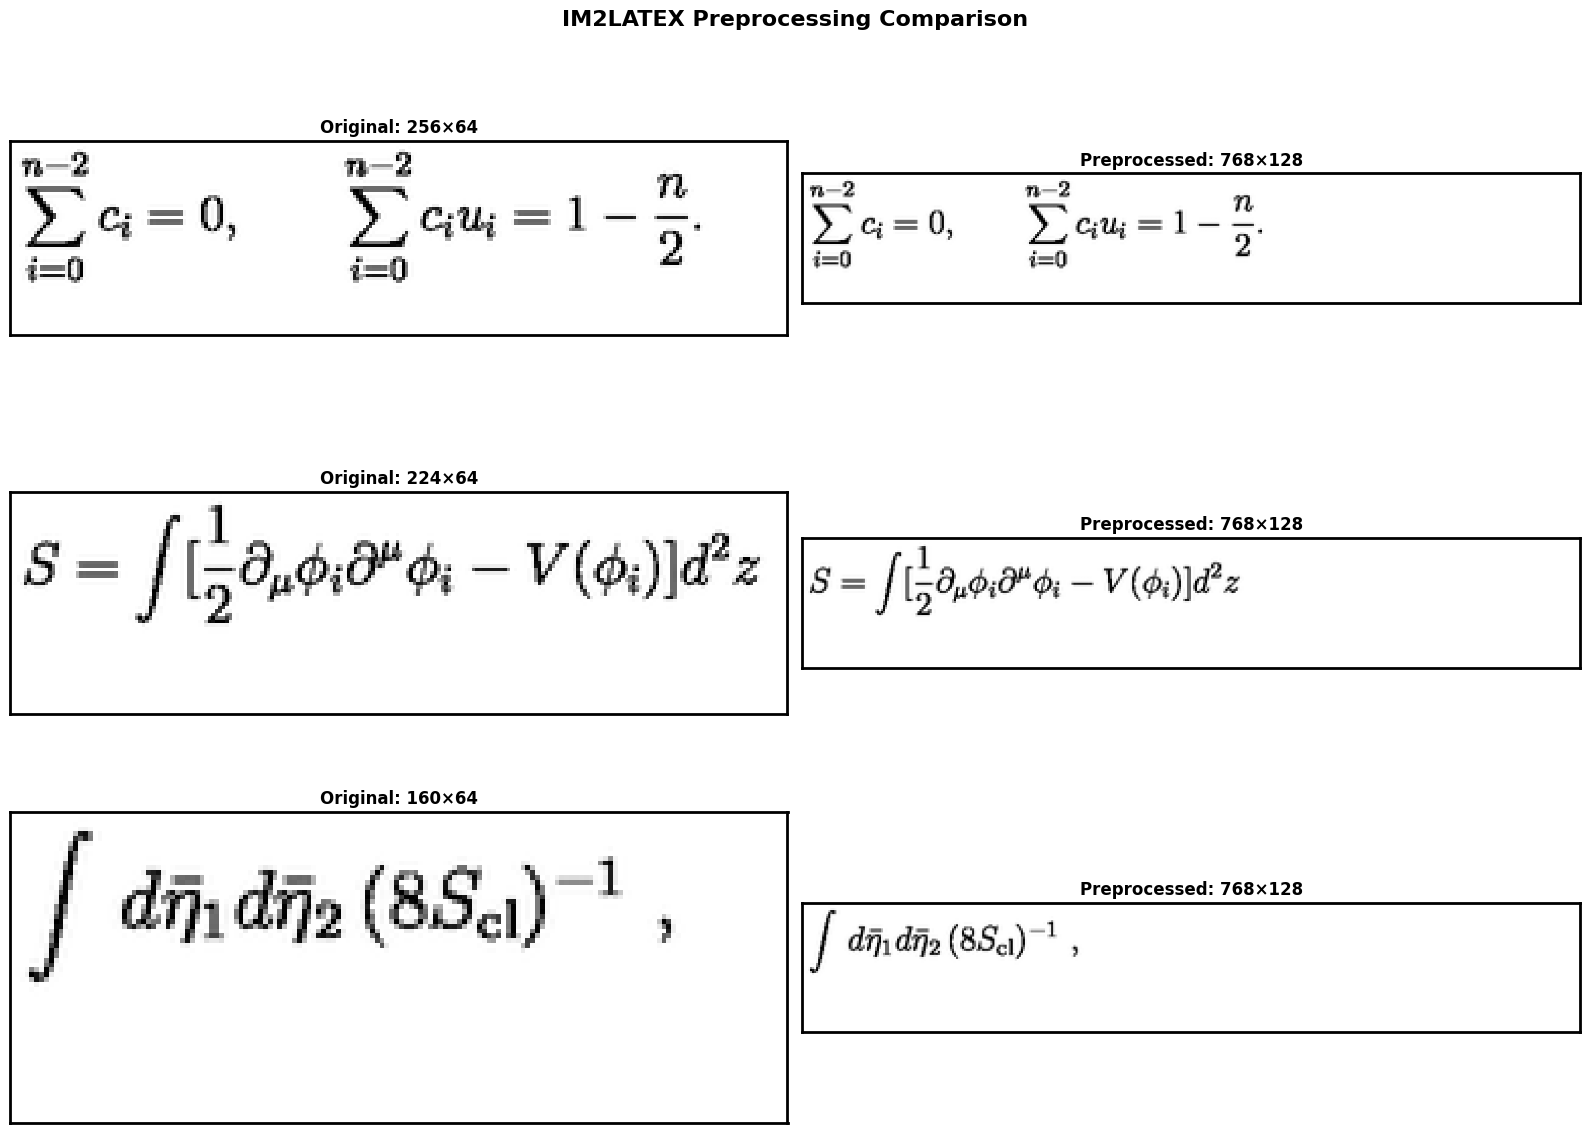

In [51]:
# Visualize IM2LATEX
print("=== IM2LATEX Preprocessing ===")
visualize_preprocessing('im2latex', num_samples=3)

=== CROHME Preprocessing ===


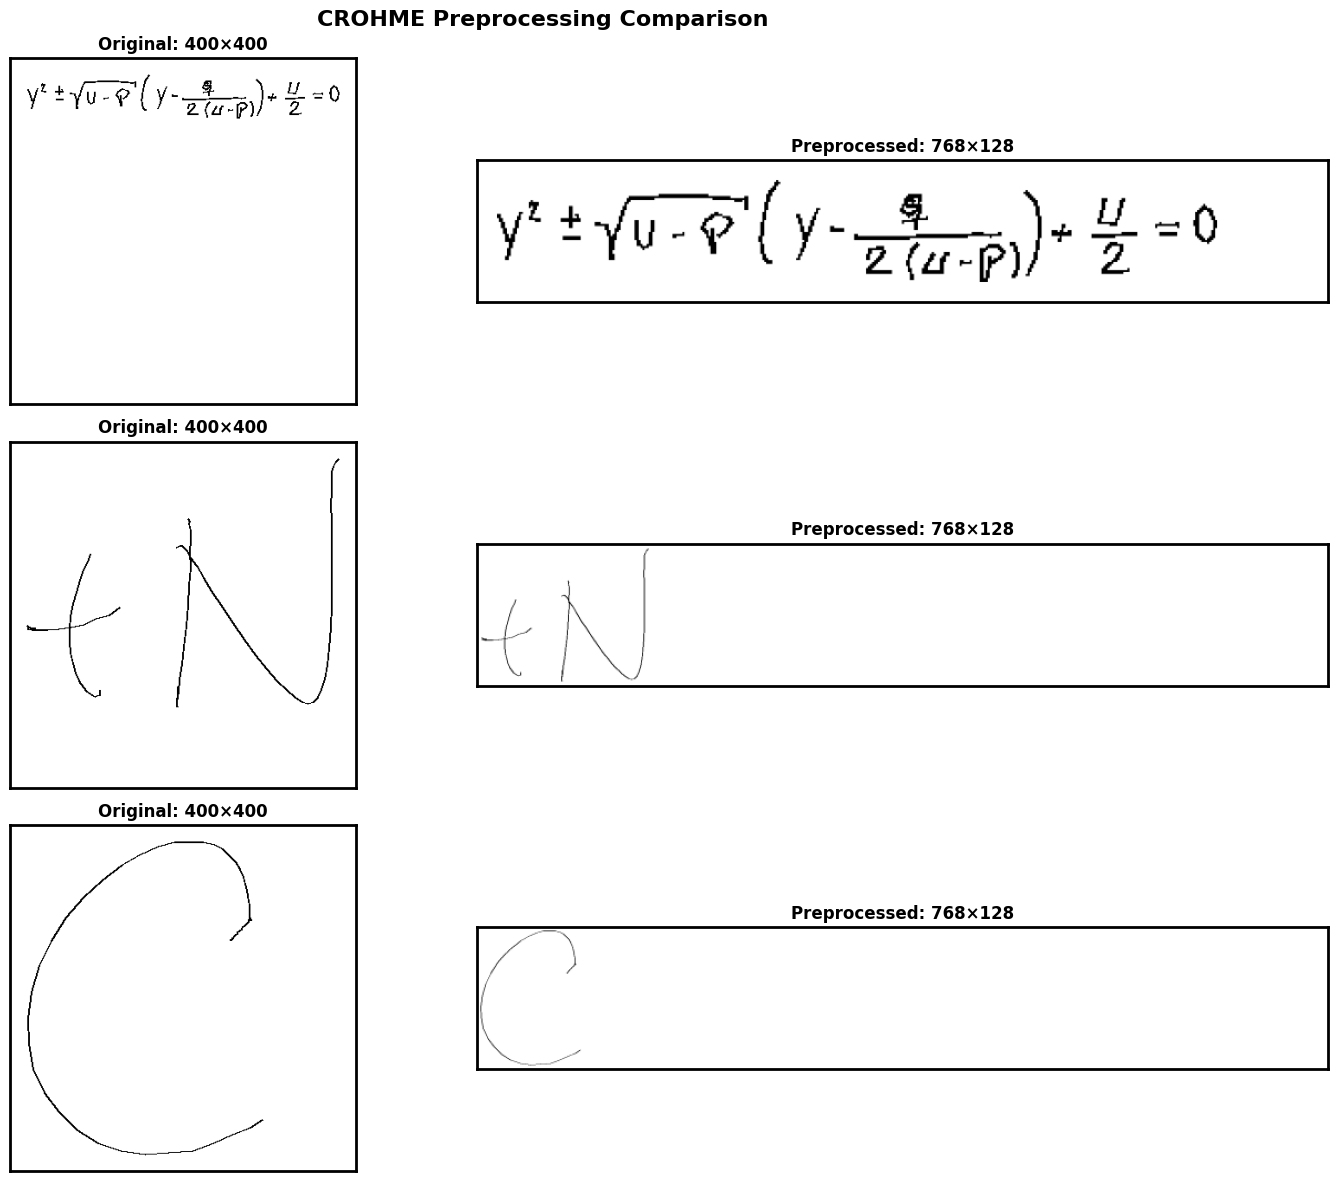

In [52]:
# Visualize CROHME
print("=== CROHME Preprocessing ===")
visualize_preprocessing('crohme', num_samples=3)

### Check CROHME Cropping Effectiveness

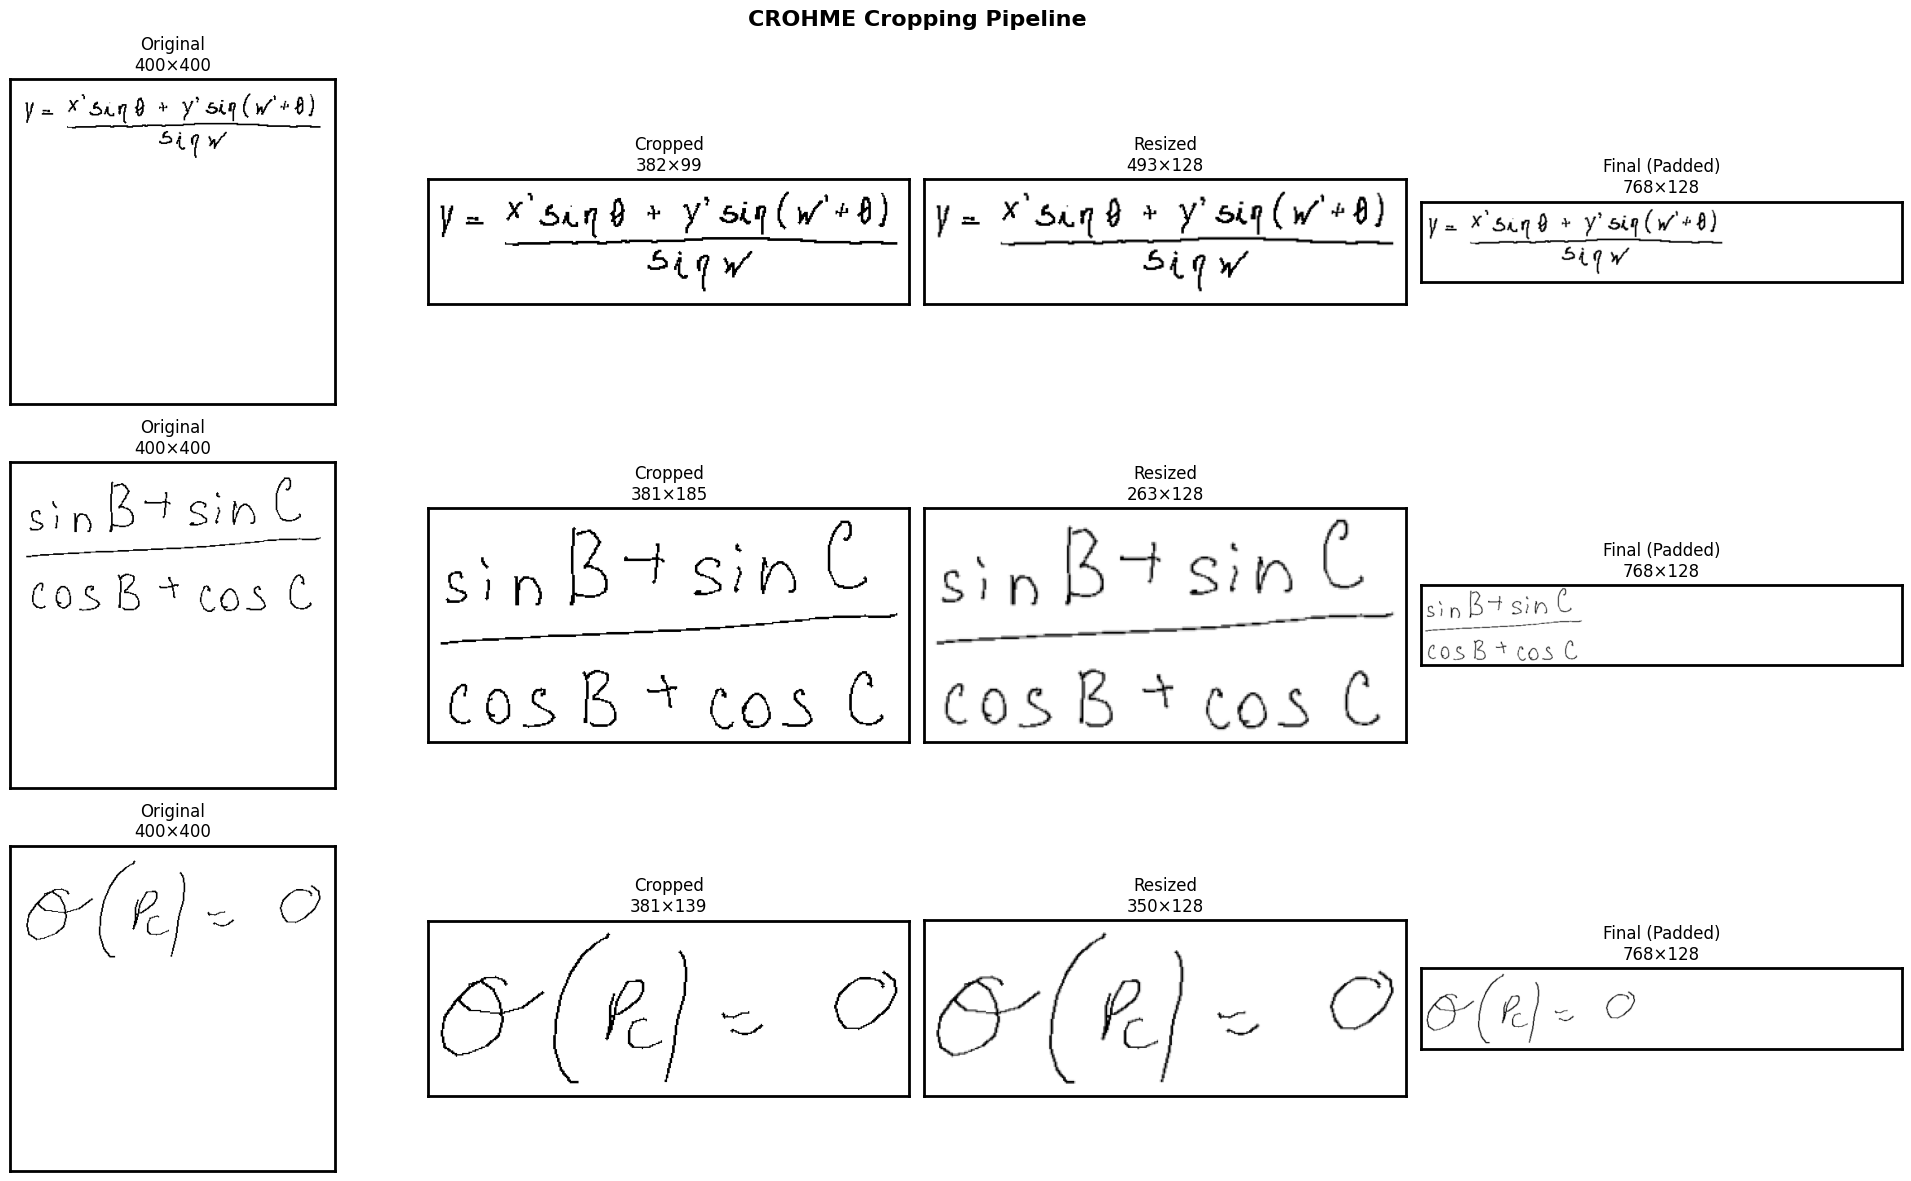

In [59]:
def add_axes_border(ax, lw=2, color='black'):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(lw)
        spine.set_edgecolor(color)

def visualize_crohme_cropping(num_samples=3):
    """
    Visualize the effect of content cropping on CROHME images.
    Shows: Original → Cropped → Resized → Final
    """
    df = crohme_df.sample(n=num_samples, random_state=43)
    img_paths = [CROHME_IMG_PATH / img for img in df['image'].values]
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(img_paths):
        # Step-by-step processing
        original = np.array(Image.open(img_path).convert('L'))
        cropped  = crop_content(original, margin=10)
        resized  = resize_keep_aspect_ratio(cropped, TARGET_HEIGHT)
        final    = pad_to_width(resized, TARGET_WIDTH)
        
        imgs = [original, cropped, resized, final]
        titles = [
            f'Original\n{original.shape[1]}×{original.shape[0]}',
            f'Cropped\n{cropped.shape[1]}×{cropped.shape[0]}',
            f'Resized\n{resized.shape[1]}×{resized.shape[0]}',
            f'Final (Padded)\n{final.shape[1]}×{final.shape[0]}'
        ]
        
        for j in range(4):
            ax = axes[idx, j]
            ax.imshow(imgs[j], cmap='gray')
            ax.set_title(titles[j])
            ax.set_xticks([]); ax.set_yticks([])   # hoặc ax.axis('off') nhưng sẽ tắt cả frame
            add_axes_border(ax, lw=2, color='black') # đổi màu/độ dày tuỳ bạn
    
    plt.suptitle('CROHME Cropping Pipeline', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_crohme_cropping(num_samples=3)


---

## Augmentation Visualization

Compare preprocessing with and without augmentation.

=== IM2LATEX Augmentation (Minimal) ===


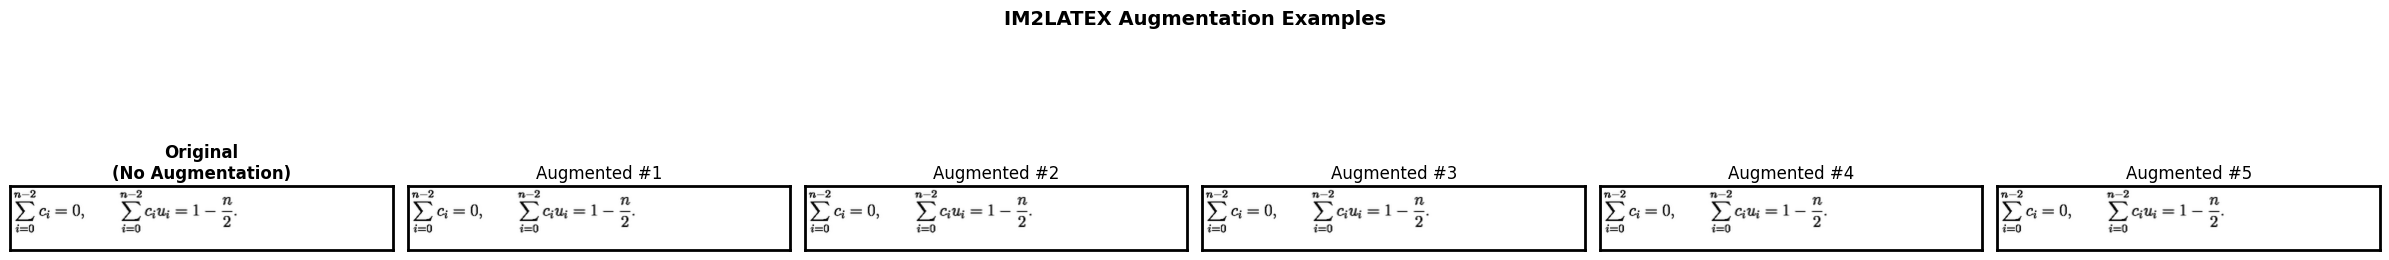

In [64]:
def add_black_border(ax, lw=2):
    # Ẩn ticks nhưng vẫn giữ khung
    ax.set_xticks([])
    ax.set_yticks([])
    # Bật viền (spines)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(lw)
        spine.set_edgecolor('black')

def visualize_augmentation(dataset_type='crohme', num_augmentations=5):
    """
    Show effect of augmentation.
    
    Args:
        dataset_type: 'im2latex' or 'crohme'
        num_augmentations: number of augmented versions to show
    """
    if dataset_type == 'im2latex':
        df = im2latex_train.sample(n=1, random_state=42)
        img_path = IM2LATEX_IMG_PATH / df['image'].values[0]
        preprocess_fn = preprocess_im2latex
    else:
        df = crohme_df.sample(n=1, random_state=42)
        img_path = CROHME_IMG_PATH / df['image'].values[0]
        preprocess_fn = preprocess_crohme
    
    fig, axes = plt.subplots(1, num_augmentations + 1, 
                             figsize=(4 * (num_augmentations + 1), 4))
    
    # Original (no augmentation)
    original = preprocess_fn(img_path, augment=False)
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original\n(No Augmentation)', fontweight='bold')
    add_black_border(axes[0], lw=2)
    
    # Augmented versions
    for i in range(num_augmentations):
        augmented = preprocess_fn(img_path, augment=True)
        axes[i + 1].imshow(augmented, cmap='gray')
        axes[i + 1].set_title(f'Augmented #{i+1}')
        add_black_border(axes[i + 1], lw=2)
    
    plt.suptitle(f'{dataset_type.upper()} Augmentation Examples', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("=== IM2LATEX Augmentation (Minimal) ===")
visualize_augmentation('im2latex', num_augmentations=5)


=== CROHME Augmentation (Aggressive) ===


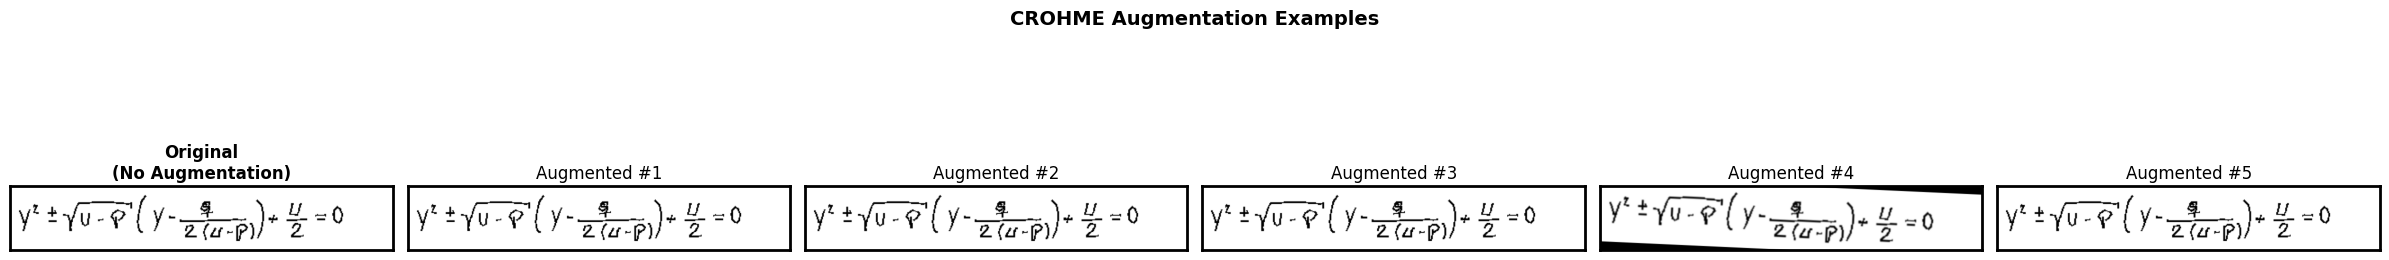

In [69]:
print("=== CROHME Augmentation (Aggressive) ===")
visualize_augmentation('crohme', num_augmentations=5)

---

## Statistics Analysis: Before vs After

Compare image statistics before and after preprocessing.

In [13]:
def _clean_finite(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    return x

def _safe_bins(x, default=30, min_bins=5):
    """
    Trả về số bins phù hợp.
    - Nếu data range ~ 0 (tất cả gần như bằng nhau) -> bins=1 (tránh lỗi).
    - Nếu ít điểm -> giảm bins.
    """
    x = _clean_finite(x)
    if x.size < 2:
        return 1
    data_range = x.max() - x.min()
    if not np.isfinite(data_range) or data_range <= 0:
        return 1
    # Quy tắc đơn giản theo số mẫu (ổn cho n≈500)
    b = int(np.sqrt(x.size))  # ~22 bins cho 500
    b = max(min_bins, min(default, b))
    return b

def analyze_preprocessing_statistics(dataset_type='im2latex', sample_size=500):
    """
    Analyze pixel statistics before and after preprocessing.
    """
    if dataset_type == 'im2latex':
        df = im2latex_train.sample(n=min(sample_size, len(im2latex_train)), random_state=42)
        img_paths = [IM2LATEX_IMG_PATH / img for img in df['image'].values]
        preprocess_fn = preprocess_im2latex
    else:
        df = crohme_df.sample(n=min(sample_size, len(crohme_df)), random_state=42)
        img_paths = [CROHME_IMG_PATH / img for img in df['image'].values]
        preprocess_fn = preprocess_crohme

    original_means, original_stds = [], []
    preprocessed_means, preprocessed_stds = [], []

    for img_path in tqdm(img_paths, desc=f"Analyzing {dataset_type}"):
        try:
            original = np.array(Image.open(img_path).convert('L'), dtype=np.float32) / 255.0
            original_means.append(float(original.mean()))
            original_stds.append(float(original.std()))

            preprocessed = preprocess_fn(img_path, augment=False)
            if preprocessed is not None:
                # đảm bảo là numpy array số
                preprocessed = np.asarray(preprocessed, dtype=np.float32)
                preprocessed_means.append(float(np.mean(preprocessed)))
                preprocessed_stds.append(float(np.std(preprocessed)))
        except Exception:
            continue

    # Clean finite values
    original_means = _clean_finite(original_means)
    original_stds = _clean_finite(original_stds)
    preprocessed_means = _clean_finite(preprocessed_means)
    preprocessed_stds = _clean_finite(preprocessed_stds)

    # Nếu preprocess trả về rỗng -> báo rõ
    if preprocessed_means.size == 0 or preprocessed_stds.size == 0:
        print("⚠️ Không có dữ liệu preprocessed (preprocess_fn trả về None hoặc lỗi).")
        return

    # Print statistics
    print(f"\n{'='*60}")
    print(f"{dataset_type.upper()} Statistics (n={len(original_means)})")
    print(f"{'='*60}")
    print(f"{'Metric':<20} {'Original':<20} {'Preprocessed':<20}")
    print(f"{'-'*60}")
    print(f"{'Mean (avg)':<20} {original_means.mean():<20.4f} {preprocessed_means.mean():<20.4f}")
    print(f"{'Mean (std)':<20} {original_means.std():<20.4f} {preprocessed_means.std():<20.4f}")
    print(f"{'Std (avg)':<20} {original_stds.mean():<20.4f} {preprocessed_stds.mean():<20.4f}")
    print(f"{'Std (std)':<20} {original_stds.std():<20.4f} {preprocessed_stds.std():<20.4f}")
    print(f"{'='*60}\n")

    # Safe bins
    bins_om = _safe_bins(original_means, default=30)
    bins_pm = _safe_bins(preprocessed_means, default=30)
    bins_os = _safe_bins(original_stds, default=30)
    bins_ps = _safe_bins(preprocessed_stds, default=30)

    # Histogram comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Mean distribution
    axes[0, 0].hist(original_means, bins=bins_om, alpha=0.7, label='Original', edgecolor='black')
    axes[0, 0].axvline(original_means.mean(), linestyle='--', label=f'Mean: {original_means.mean():.4f}')
    axes[0, 0].set_xlabel('Pixel Mean'); axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Original: Mean (bins={bins_om})')
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(preprocessed_means, bins=bins_pm, alpha=0.7, label='Preprocessed',
                    color='orange', edgecolor='black')
    axes[0, 1].axvline(preprocessed_means.mean(), color='red', linestyle='--',
                       label=f'Mean: {preprocessed_means.mean():.4f}')
    axes[0, 1].set_xlabel('Pixel Mean'); axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'Preprocessed: Mean (bins={bins_pm})')
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    # Std distribution
    axes[1, 0].hist(original_stds, bins=bins_os, alpha=0.7, label='Original', edgecolor='black')
    axes[1, 0].axvline(original_stds.mean(), linestyle='--', label=f'Mean: {original_stds.mean():.4f}')
    axes[1, 0].set_xlabel('Pixel Std'); axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'Original: Std (bins={bins_os})')
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].hist(preprocessed_stds, bins=bins_ps, alpha=0.7, label='Preprocessed',
                    color='orange', edgecolor='black')
    axes[1, 1].axvline(preprocessed_stds.mean(), color='red', linestyle='--',
                       label=f'Mean: {preprocessed_stds.mean():.4f}')
    axes[1, 1].set_xlabel('Pixel Std'); axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'Preprocessed: Std (bins={bins_ps})')
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.suptitle(f'{dataset_type.upper()}: Pixel Statistics Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


Analyzing im2latex: 100%|██████████| 500/500 [00:16<00:00, 29.49it/s]



IM2LATEX Statistics (n=500)
Metric               Original             Preprocessed        
------------------------------------------------------------
Mean (avg)           0.9438               0.9602              
Mean (std)           0.0161               0.0173              
Std (avg)            0.1907               0.1582              
Std (std)            0.0248               0.0322              



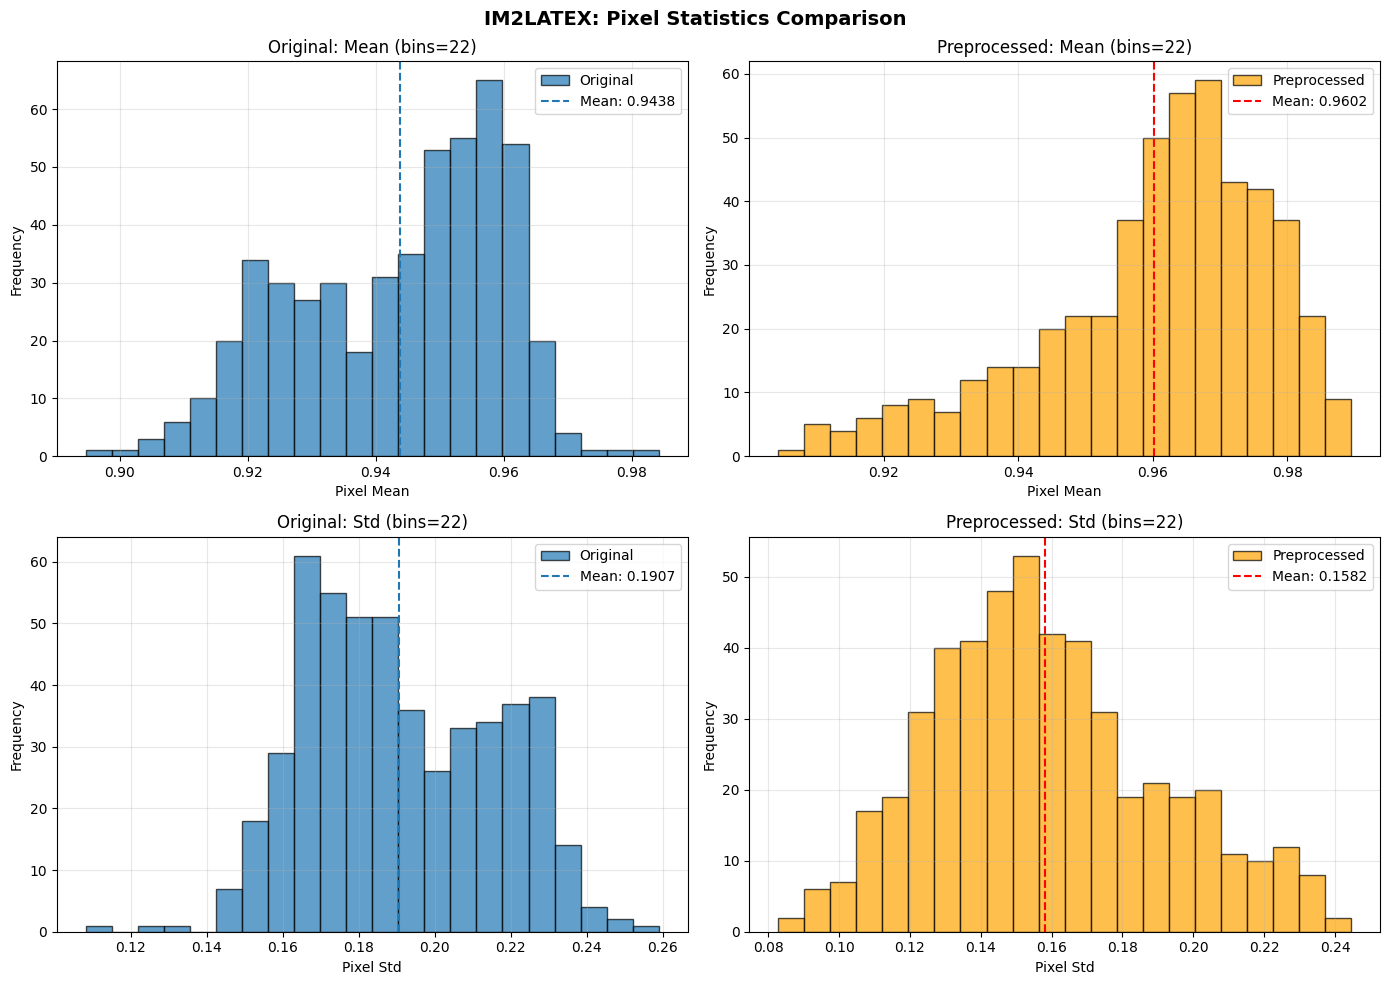

In [14]:
analyze_preprocessing_statistics('im2latex', sample_size=500)

Analyzing crohme: 100%|██████████| 500/500 [00:23<00:00, 21.27it/s]



CROHME Statistics (n=500)
Metric               Original             Preprocessed        
------------------------------------------------------------
Mean (avg)           0.9889               -0.0000             
Mean (std)           0.0041               0.0000              
Std (avg)            0.1032               1.0000              
Std (std)            0.0187               0.0000              



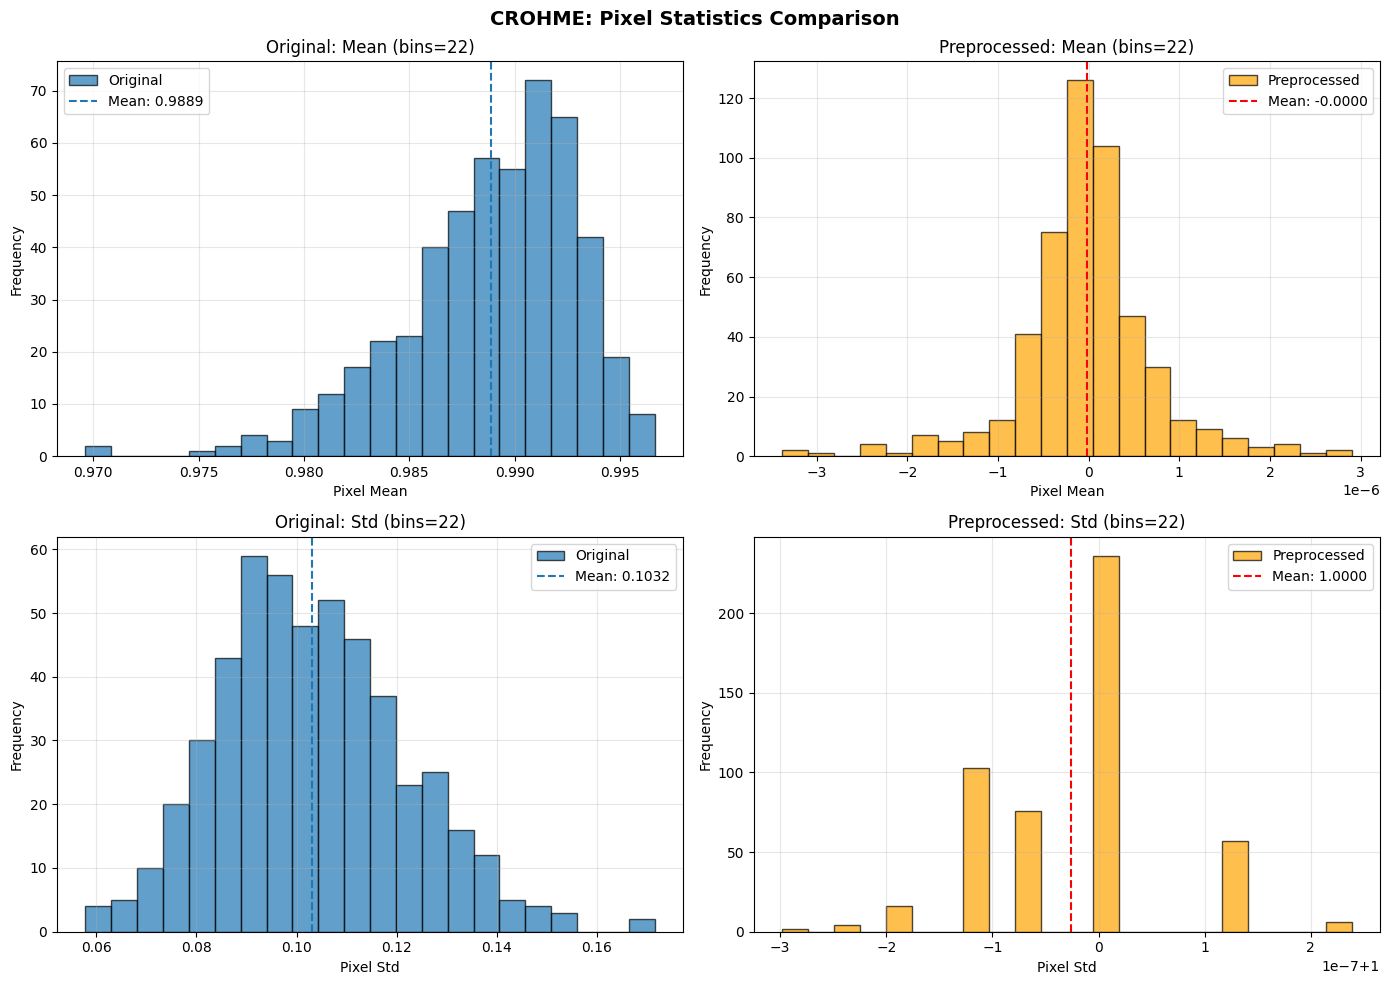

In [15]:
analyze_preprocessing_statistics('crohme', sample_size=500)

---

## Batch Processing & Save Preprocessed Images

Process all images and save to disk for training.

In [16]:
def batch_preprocess_and_save(dataset_type='im2latex', save_images=True):
    """
    Batch preprocess all images and optionally save to disk.
    
    Args:
        dataset_type: 'im2latex' or 'crohme'
        save_images: whether to save preprocessed images (can be large!)
    
    Returns:
        Updated DataFrame with preprocessed image paths
    """
    if dataset_type == 'im2latex':
        # Process all splits
        train_df = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_train.csv")
        val_df = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_validate.csv")
        test_df = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_test.csv")
        
        all_dfs = {
            'train': train_df,
            'val': val_df,
            'test': test_df
        }
        
        base_path = IM2LATEX_IMG_PATH
        output_path = IM2LATEX_OUTPUT_PATH
        preprocess_fn = preprocess_im2latex
    else:
        # CROHME - need to split manually
        df = pd.read_csv(CROHME_CSV_PATH)
        
        # Split: 80% train, 10% val, 10% test
        from sklearn.model_selection import train_test_split
        train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
        
        all_dfs = {
            'train': train_df,
            'val': val_df,
            'test': test_df
        }
        
        base_path = CROHME_IMG_PATH
        output_path = CROHME_OUTPUT_PATH
        preprocess_fn = preprocess_crohme
    
    # Process each split
    for split_name, df in all_dfs.items():
        print(f"\n{'='*60}")
        print(f"Processing {dataset_type.upper()} - {split_name.upper()} split")
        print(f"{'='*60}")
        
        # Create output directory
        split_output_path = output_path / split_name
        split_output_path.mkdir(exist_ok=True)
        
        preprocessed_paths = []
        valid_indices = []
        
        for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
            img_path = base_path / row['image']
            
            # Preprocess
            preprocessed = preprocess_fn(img_path, augment=False)
            
            if preprocessed is not None:
                if save_images:
                    # Save as numpy array (more efficient than image files)
                    output_filename = Path(row['image']).stem + '.npy'
                    output_file = split_output_path / output_filename
                    np.save(output_file, preprocessed)
                    preprocessed_paths.append(str(output_file))
                else:
                    preprocessed_paths.append(None)
                
                valid_indices.append(idx)
        
        # Update DataFrame
        valid_df = df.loc[valid_indices].copy()
        if save_images:
            valid_df['preprocessed_path'] = preprocessed_paths
        
        # Save updated CSV
        output_csv = output_path / f"{split_name}.csv"
        valid_df.to_csv(output_csv, index=False)
        
        print(f"✓ Processed {len(valid_df)} / {len(df)} images")
        print(f"✓ Saved to: {output_csv}")
        
        all_dfs[split_name] = valid_df
    
    return all_dfs


print("✓ Batch processing function ready")
print("\nNote: Saving all preprocessed images will require significant disk space.")
print("Consider processing on-the-fly during training instead.")

✓ Batch processing function ready

Note: Saving all preprocessed images will require significant disk space.
Consider processing on-the-fly during training instead.


In [17]:
# Process IM2LATEX (this will take time!)
# Set save_images=False to only create CSV files without saving images
# Images will be preprocessed on-the-fly during training

print("Processing IM2LATEX dataset...")
im2latex_splits = batch_preprocess_and_save('im2latex', save_images=True)

Processing IM2LATEX dataset...

Processing IM2LATEX - TRAIN split


Processing train: 100%|██████████| 75275/75275 [29:40<00:00, 42.28it/s]


✓ Processed 75275 / 75275 images
✓ Saved to: /app/data/preprocessed/im2latex/train.csv

Processing IM2LATEX - VAL split


Processing val: 100%|██████████| 8370/8370 [04:26<00:00, 31.42it/s]


✓ Processed 8370 / 8370 images
✓ Saved to: /app/data/preprocessed/im2latex/val.csv

Processing IM2LATEX - TEST split


Processing test: 100%|██████████| 10355/10355 [03:19<00:00, 51.87it/s]


✓ Processed 10355 / 10355 images
✓ Saved to: /app/data/preprocessed/im2latex/test.csv


In [18]:
# Process CROHME
print("Processing CROHME dataset...")
crohme_splits = batch_preprocess_and_save('crohme', save_images=True)

Processing CROHME dataset...

Processing CROHME - TRAIN split


Processing train: 100%|██████████| 15084/15084 [04:45<00:00, 52.84it/s]


✓ Processed 15084 / 15084 images
✓ Saved to: /app/data/preprocessed/crohme/train.csv

Processing CROHME - VAL split


Processing val: 100%|██████████| 1885/1885 [00:28<00:00, 65.10it/s]


✓ Processed 1885 / 1885 images
✓ Saved to: /app/data/preprocessed/crohme/val.csv

Processing CROHME - TEST split


Processing test: 100%|██████████| 1886/1886 [00:28<00:00, 67.24it/s]

✓ Processed 1886 / 1886 images
✓ Saved to: /app/data/preprocessed/crohme/test.csv


---

## Summary & Validation

Final checks and statistics.

In [19]:
# Summary statistics
print("="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print("\n📊 IM2LATEX Dataset:")
print(f"  Train:      {len(im2latex_splits['train']):>6,} samples")
print(f"  Validation: {len(im2latex_splits['val']):>6,} samples")
print(f"  Test:       {len(im2latex_splits['test']):>6,} samples")
print(f"  Total:      {sum(len(df) for df in im2latex_splits.values()):>6,} samples")

print("\n📊 CROHME Dataset:")
print(f"  Train:      {len(crohme_splits['train']):>6,} samples")
print(f"  Validation: {len(crohme_splits['val']):>6,} samples")
print(f"  Test:       {len(crohme_splits['test']):>6,} samples")
print(f"  Total:      {sum(len(df) for df in crohme_splits.values()):>6,} samples")

print("\n🎯 Canonical Format:")
print(f"  Shape:      [{NUM_CHANNELS}, {TARGET_HEIGHT}, {TARGET_WIDTH}]")
print(f"  Channels:   Grayscale (1 channel)")
print(f"  Height:     Fixed at {TARGET_HEIGHT} pixels")
print(f"  Width:      Padded to {TARGET_WIDTH} pixels")

print("\n✅ Preprocessing Strategy:")
print("  IM2LATEX:   Minimal processing, preserve sharpness")
print("  CROHME:     Content cropping + contrast enhancement")

print("\n📁 Output Files:")
print(f"  IM2LATEX:   {IM2LATEX_OUTPUT_PATH}")
print(f"  CROHME:     {CROHME_OUTPUT_PATH}")
print("="*70)

PREPROCESSING SUMMARY

📊 IM2LATEX Dataset:
  Train:      75,275 samples
  Validation:  8,370 samples
  Test:       10,355 samples
  Total:      94,000 samples

📊 CROHME Dataset:
  Train:      15,084 samples
  Validation:  1,885 samples
  Test:        1,886 samples
  Total:      18,855 samples

🎯 Canonical Format:
  Shape:      [1, 128, 768]
  Channels:   Grayscale (1 channel)
  Height:     Fixed at 128 pixels
  Width:      Padded to 768 pixels

✅ Preprocessing Strategy:
  IM2LATEX:   Minimal processing, preserve sharpness
  CROHME:     Content cropping + contrast enhancement

📁 Output Files:
  IM2LATEX:   /app/data/preprocessed/im2latex
  CROHME:     /app/data/preprocessed/crohme


---

## Key Findings & Next Steps

1. **Unified Format**: Both datasets now follow canonical `[1, 128, 768]` format
2. **Fixed CROHME Issues**: 
   - Content cropping removes excess whitespace
   - Aspect ratio is now preserved (not forced to square)
   - Contrast enhancement addresses low std problem
3. **Domain-Specific Processing**:
   - IM2LATEX: Minimal processing, preserves print quality
   - CROHME: Aggressive preprocessing for handwriting

### 📋 Next Steps:

1. **Implement Dataset Classes** (`src/datasets/`):
   - `IM2LATEXDataset`: Load and preprocess on-the-fly
   - `CROHMEDataset`: Load and preprocess on-the-fly
   - Include augmentation for training split

2. **Tokenizer & Vocabulary** (from EDA recommendations):
   - Build unified vocabulary from IM2LATEX base
   - Add special tokens: `<PAD>`, `<BOS>`, `<EOS>`, `<UNK>`
   - Handle CROHME label cleaning

3. **Model Architecture**:
   - Encoder: CNN (ResNet/EfficientNet) for `[1, 128, 768]` input
   - Decoder: Transformer/LSTM with attention
   - Position embeddings for max_seq_len=150

4. **Training Strategy**:
   - Phase 1: Pretrain on IM2LATEX (94k samples)
   - Phase 2: Fine-tune on CROHME (18k samples)
   - Monitor domain gap and catastrophic forgetting

### ⚠️ Important Notes:

- **On-the-fly preprocessing recommended**: Saves disk space, allows dynamic augmentation
- **Augmentation during training only**: Validation/test use deterministic preprocessing
- **Monitor preprocessing time**: May need optimization (caching, multiprocessing)

---

**End of Preprocessing Pipeline** ✓

---

## 🔍 Deep Dive: Ảnh dạng Numpy - Model hiểu như thế nào?

Giải thích chi tiết về cấu trúc dữ liệu và cách model xử lý.

In [20]:
# Load 1 ảnh preprocessed để phân tích chi tiết
sample_npy_path = Path('/app/data/preprocessed/crohme/test/101_Nina.npy')
preprocessed_img = np.load(sample_npy_path)

print("="*70)
print("ẢNH LÀ GỈ? - Góc nhìn của Model")
print("="*70)

print("\n📌 BẢN CHẤT CỦA ẢNH:")
print("-" * 70)
print("✓ Ảnh KHÔNG phải là 'hình vẽ' mà là MÃ TRẬN SỐ")
print("✓ Mỗi pixel (điểm ảnh) = 1 giá trị số")
print("✓ Model đọc ảnh = Model đọc ma trận số")
print()

print("📊 THÔNG TIN MA TRẬN:")
print(f"  Shape:        {preprocessed_img.shape}")
print(f"  Kiểu dữ liệu: {preprocessed_img.dtype}")
print(f"  Số pixels:    {preprocessed_img.size:,} pixels")
print(f"  Kích thước:   {preprocessed_img.nbytes / 1024:.1f} KB")
print()

print("📈 PHÂN BỐ GIÁ TRỊ PIXEL:")
print(f"  Min:  {preprocessed_img.min():.4f}  ← Pixel TỐI (nét viết)")
print(f"  Max:  {preprocessed_img.max():.4f}  ← Pixel SÁNG (nền trắng)")
print(f"  Mean: {preprocessed_img.mean():.4f}  ← Trung bình (chuẩn hóa về 0)")
print(f"  Std:  {preprocessed_img.std():.4f}   ← Độ lệch chuẩn (chuẩn hóa về 1)")
print()

print("🔢 MỘT PHẦN MA TRẬN (5 hàng đầu, 10 cột đầu):")
print(preprocessed_img[:5, :10])
print()

print("="*70)
print("💡 GIẢI THÍCH:")
print("="*70)
print("Mỗi số trong ma trận đại diện cho ĐỘ SÁNG của 1 pixel:")
print("  • Số DƯƠNG (+0.19): Vùng TRẮNG (nền, padding)")
print("  • Số ÂM    (-6.13): Vùng ĐEN (nét viết, công thức)")
print("  • Số GẦN 0 (0.00):  Vùng XÁM (viền, chuyển tiếp)")
print()
print("Model học cách:")
print("  1. Nhận diện PATTERN trong ma trận số này")
print("  2. Tìm đặc trưng: 'Pixel tối tạo thành hình dáng gì?'")
print("  3. Ánh xạ sang ký hiệu LaTeX tương ứng")
print("="*70)

ẢNH LÀ GỈ? - Góc nhìn của Model

📌 BẢN CHẤT CỦA ẢNH:
----------------------------------------------------------------------
✓ Ảnh KHÔNG phải là 'hình vẽ' mà là MÃ TRẬN SỐ
✓ Mỗi pixel (điểm ảnh) = 1 giá trị số
✓ Model đọc ảnh = Model đọc ma trận số

📊 THÔNG TIN MA TRẬN:
  Shape:        (128, 768)
  Kiểu dữ liệu: float32
  Số pixels:    98,304 pixels
  Kích thước:   384.0 KB

📈 PHÂN BỐ GIÁ TRỊ PIXEL:
  Min:  -6.1299  ← Pixel TỐI (nét viết)
  Max:  0.1919  ← Pixel SÁNG (nền trắng)
  Mean: -0.0000  ← Trung bình (chuẩn hóa về 0)
  Std:  1.0000   ← Độ lệch chuẩn (chuẩn hóa về 1)

🔢 MỘT PHẦN MA TRẬN (5 hàng đầu, 10 cột đầu):
[[0.19194013 0.19194013 0.19194013 0.19194013 0.19194013 0.19194013
  0.19194013 0.19194013 0.19194013 0.19194013]
 [0.19194013 0.19194013 0.19194013 0.19194013 0.19194013 0.19194013
  0.19194013 0.19194013 0.19194013 0.19194013]
 [0.19194013 0.19194013 0.19194013 0.19194013 0.19194013 0.19194013
  0.19194013 0.19194013 0.19194013 0.19194013]
 [0.19194013 0.19194013 0.191

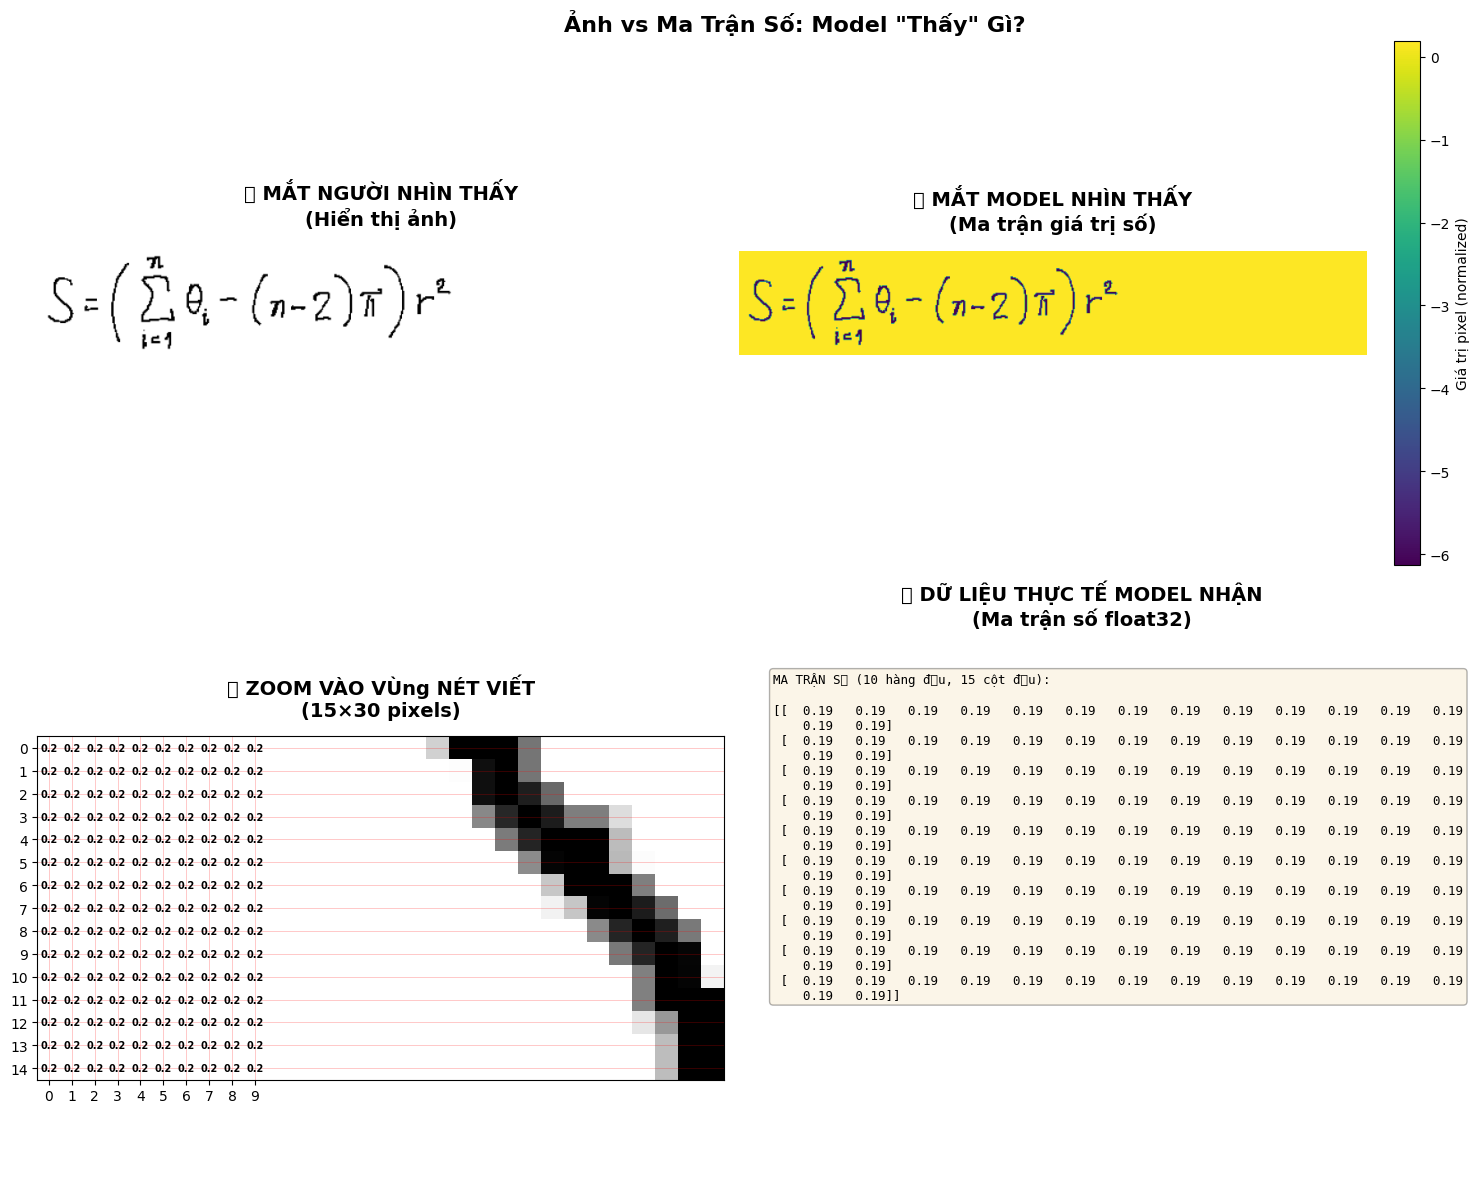


💡 GIẢI THÍCH VISUALIZATION:
TOP-LEFT:  Ảnh như bạn nhìn thấy (grayscale)
TOP-RIGHT: Ảnh với màu sắc theo giá trị số (heatmap)
           - Màu TÍM/XANH: Giá trị âm (nét viết)
           - Màu VÀNG:     Giá trị dương (nền trắng)

BOTTOM-LEFT:  Zoom vào 1 vùng nhỏ với GIÁ TRỊ SỐ hiển thị
              Model đọc CHÍNH XÁC những con số này!

BOTTOM-RIGHT: Ma trận số dạng text - đây là INPUT của model


In [21]:
# Visualization: So sánh giữa "mắt người" và "mắt model"
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ảnh như MẮT NGƯỜI thấy
axes[0, 0].imshow(preprocessed_img, cmap='gray')
axes[0, 0].set_title('👁️ MẮT NGƯỜI NHÌN THẤY\n(Hiển thị ảnh)', 
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].axis('off')

# 2. Ảnh như MẮT MODEL thấy (heatmap)
im = axes[0, 1].imshow(preprocessed_img, cmap='viridis')
axes[0, 1].set_title('🤖 MẮT MODEL NHÌN THẤY\n(Ma trận giá trị số)', 
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04, 
             label='Giá trị pixel (normalized)')

# 3. Zoom vào một vùng nhỏ: Ma trận số
zoom_region = preprocessed_img[40:55, 100:130]  # Vùng có nét viết
axes[1, 0].imshow(zoom_region, cmap='gray', interpolation='nearest')
axes[1, 0].set_title('🔍 ZOOM VÀO VÙng NÉT VIẾT\n(15×30 pixels)', 
                     fontsize=14, fontweight='bold', pad=15)

# Hiển thị grid và giá trị số
for i in range(zoom_region.shape[0]):
    for j in range(min(10, zoom_region.shape[1])):  # Chỉ hiện 10 cột đầu
        value = zoom_region[i, j]
        color = 'white' if value < -1 else 'black'
        axes[1, 0].text(j, i, f'{value:.1f}', 
                       ha='center', va='center', 
                       fontsize=7, color=color, fontweight='bold')

axes[1, 0].set_xticks(range(min(10, zoom_region.shape[1])))
axes[1, 0].set_yticks(range(zoom_region.shape[0]))
axes[1, 0].grid(True, color='red', linewidth=0.5, alpha=0.3)

# 4. Ma trận số dạng text (góc trái trên)
sample_matrix = preprocessed_img[:10, :15]
matrix_text = "MA TRẬN SỐ (10 hàng đầu, 15 cột đầu):\n\n"
matrix_text += np.array2string(sample_matrix, 
                               formatter={'float_kind': lambda x: f"{x:6.2f}"},
                               max_line_width=100)

axes[1, 1].text(0.05, 0.95, matrix_text, 
               transform=axes[1, 1].transAxes,
               fontsize=9, verticalalignment='top',
               fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].set_title('📝 DỮ LIỆU THỰC TẾ MODEL NHẬN\n(Ma trận số float32)', 
                     fontsize=14, fontweight='bold', pad=15)
axes[1, 1].axis('off')

plt.suptitle('Ảnh vs Ma Trận Số: Model "Thấy" Gì?', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n💡 GIẢI THÍCH VISUALIZATION:")
print("="*70)
print("TOP-LEFT:  Ảnh như bạn nhìn thấy (grayscale)")
print("TOP-RIGHT: Ảnh với màu sắc theo giá trị số (heatmap)")
print("           - Màu TÍM/XANH: Giá trị âm (nét viết)")
print("           - Màu VÀNG:     Giá trị dương (nền trắng)")
print()
print("BOTTOM-LEFT:  Zoom vào 1 vùng nhỏ với GIÁ TRỊ SỐ hiển thị")
print("              Model đọc CHÍNH XÁC những con số này!")
print()
print("BOTTOM-RIGHT: Ma trận số dạng text - đây là INPUT của model")
print("="*70)

### Luồng xử lý: Từ ảnh → Model → LaTeX

In [22]:
print("="*80)
print("🔄 LUỒNG XỬ LÝ: TỪ ẢNH GỐC → MODEL → LATEX")
print("="*80)

print("\n📸 BƯỚC 1: ẢNH GỐC")
print("-" * 80)
print("  Input:  File ảnh .png/.jpg (ví dụ: '101_Nina.png')")
print("  Format: RGB/Grayscale, kích thước bất kỳ (ví dụ: 450×320)")
print("  Dữ liệu: Ma trận pixel với giá trị 0-255 (uint8)")
print()

print("🔧 BƯỚC 2: PREPROCESSING")
print("-" * 80)
print("  ① Grayscale:       RGB → Grayscale (3 channels → 1 channel)")
print("  ② Crop:            Cắt bỏ whitespace thừa (450×320 → 280×220)")
print("  ③ Resize:          Giữ tỉ lệ, scale về height=128 (280×220 → 158×128)")
print("  ④ Pad:             Thêm padding trắng về width=768 (158×128 → 768×128)")
print("  ⑤ Normalize:       Per-image normalize (mean=0, std=1)")
print()
print(f"  Output: Numpy array shape {preprocessed_img.shape}, dtype {preprocessed_img.dtype}")
print(f"  Lưu vào: .npy file (384 KB)")
print()

print("💾 BƯỚC 3: LƯU TRỮ & LOAD")
print("-" * 80)
print("  • File .npy chứa ma trận số CHÍNH XÁC như sau preprocessing")
print("  • Khi training: np.load('101_Nina.npy') → lấy ngay ma trận (128, 768)")
print("  • KHÔNG cần preprocess lại → Tiết kiệm thời gian!")
print()

print("🧠 BƯỚC 4: MODEL XỬ LÝ")
print("-" * 80)
print("  Input shape:  (batch_size, 1, 128, 768)")
print("                 ↑           ↑   ↑    ↑")
print("                 |           |   |    └─ Width (pixels)")
print("                 |           |   └────── Height (pixels)")
print("                 |           └────────── Channels (grayscale)")
print("                 └────────────────────── Số ảnh trong 1 batch")
print()
print("  Encoder (CNN):")
print("    • Convolutional layers: Trích xuất FEATURES từ ma trận pixel")
print("    • Học các PATTERN: nét cong, nét thẳng, góc, vòng tròn...")
print("    • Output: Feature maps (vectors đại diện cho ảnh)")
print()
print("  Decoder (Transformer/LSTM):")
print("    • Nhận features từ encoder")
print("    • Sinh ra LaTeX TỪNG TOKEN MỘT")
print("    • Ví dụ: ['\\\\frac', '{', 'x', '}', '{', '2', '}']")
print()

print("📝 BƯỚC 5: OUTPUT LATEX")
print("-" * 80)
print("  Output: Chuỗi LaTeX (ví dụ: '\\\\frac{x}{2} + y^2 = 0')")
print("  Render: Hiển thị công thức toán học")
print()

print("="*80)
print("🎯 TÓM TẮT: Model 'HIỂU' GÌ?")
print("="*80)
print("Model KHÔNG 'thấy' hình ảnh như con người!")
print("Model chỉ nhìn thấy: MÃ TRẬN SỐ (128×768 = 98,304 số float32)")
print()
print("Qua training, model học được:")
print("  ✓ Pattern trong ma trận → Ý nghĩa toán học")
print("  ✓ Vị trí pixel tối → Hình dạng ký tự")
print("  ✓ Cấu trúc không gian → Thứ tự ký hiệu")
print()
print("Ví dụ cụ thể:")
print("  • Ma trận có pixels tối tạo thành 'hình ngang' → Token: '-' ")
print("  • Ma trận có pixels tối tạo thành 'góc vuông' → Token: '\\\\sqrt'")
print("  • Pattern phức tạp hơn → Kết hợp nhiều token → Công thức hoàn chỉnh")
print("="*80)

🔄 LUỒNG XỬ LÝ: TỪ ẢNH GỐC → MODEL → LATEX

📸 BƯỚC 1: ẢNH GỐC
--------------------------------------------------------------------------------
  Input:  File ảnh .png/.jpg (ví dụ: '101_Nina.png')
  Format: RGB/Grayscale, kích thước bất kỳ (ví dụ: 450×320)
  Dữ liệu: Ma trận pixel với giá trị 0-255 (uint8)

🔧 BƯỚC 2: PREPROCESSING
--------------------------------------------------------------------------------
  ① Grayscale:       RGB → Grayscale (3 channels → 1 channel)
  ② Crop:            Cắt bỏ whitespace thừa (450×320 → 280×220)
  ③ Resize:          Giữ tỉ lệ, scale về height=128 (280×220 → 158×128)
  ④ Pad:             Thêm padding trắng về width=768 (158×128 → 768×128)
  ⑤ Normalize:       Per-image normalize (mean=0, std=1)

  Output: Numpy array shape (128, 768), dtype float32
  Lưu vào: .npy file (384 KB)

💾 BƯỚC 3: LƯU TRỮ & LOAD
--------------------------------------------------------------------------------
  • File .npy chứa ma trận số CHÍNH XÁC như sau preprocessing
  • Kh